# 1. Investigate the data and verify the dataloader

Inputs are physiological **waveforms** (ECG, PPG, ABP); the blood-pressure target is a
pair of **scalars** (SBP, DBP) per segment. We do not trust channel labels -- we verify
each channel from physics. Everything loads from the bundled `data/vitaldb_mini.npz`


In [1]:
import numpy as np, matplotlib.pyplot as plt
from scipy.stats import kurtosis
import mechlib
plt.rcParams.update({"axes.spines.top":False,"axes.spines.right":False,"font.size":10})
NAVY, RED, GREEN = "#2f4b7c", "#c1543b", "#3b8c5a"

d = mechlib.load_mini("data/vitaldb_mini.npz")
Xtr, ytr, fs = d["Xtr"], d["ytr"], d["fs"]
print("train signals :", Xtr.shape, " (segments, samples, channels)")
print("train labels  :", ytr.shape, " (segments, [SBP, DBP])")
print(f"one segment   : {Xtr.shape[1]} samples at {fs} Hz = {Xtr.shape[1]/fs:.0f} s")
print("INPUT = waveforms (N, L, 3).  TARGET = scalar BP (SBP, DBP) per segment.")

train signals : (4000, 1250, 3)  (segments, samples, channels)
train labels  : (4000, 2)  (segments, [SBP, DBP])
one segment   : 1250 samples at 125 Hz = 10 s
INPUT = waveforms (N, L, 3).  TARGET = scalar BP (SBP, DBP) per segment.


## What is in the data



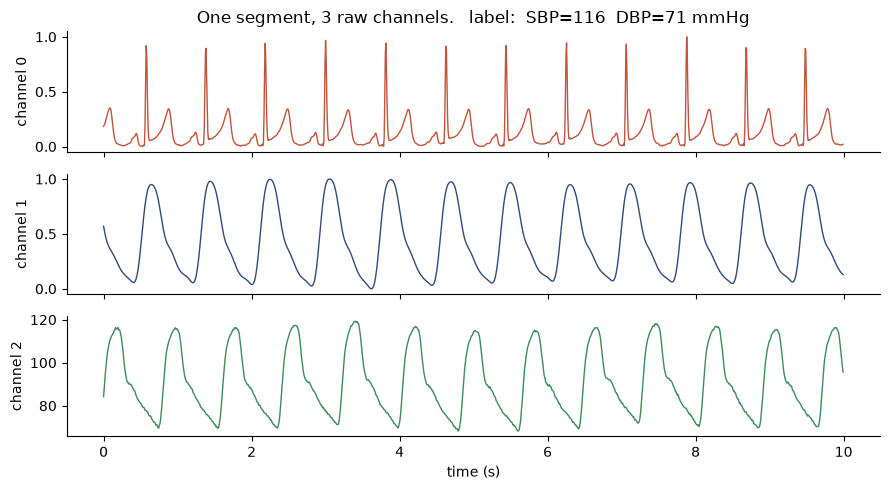

In [2]:
t = np.arange(Xtr.shape[1]) / fs
fig, ax = plt.subplots(3, 1, figsize=(9, 5), sharex=True)
for c, col in zip(range(3), [RED, NAVY, GREEN]):
    ax[c].plot(t, Xtr[0, :, c], color=col, lw=1); ax[c].set_ylabel(f"channel {c}")
ax[0].set_title(f"One segment, 3 raw channels.   label:  SBP={ytr[0,0]:.0f}  DBP={ytr[0,1]:.0f} mmHg")
ax[-1].set_xlabel("time (s)"); fig.tight_layout(); plt.show()

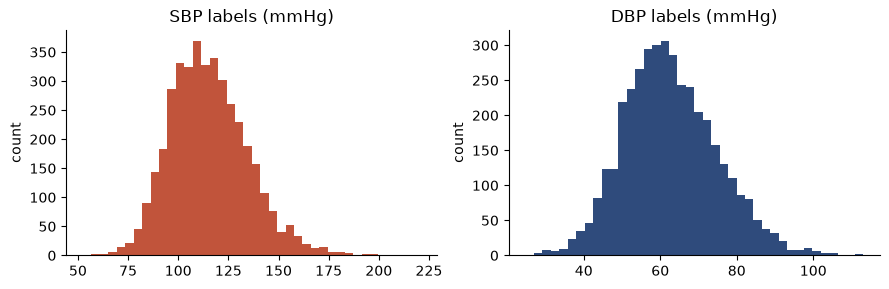

SBP 115 +/- 19 mmHg   DBP 63 +/- 12 mmHg


In [3]:
fig, ax = plt.subplots(1, 2, figsize=(9, 3))
ax[0].hist(ytr[:,0], bins=40, color=RED);  ax[0].set_title("SBP labels (mmHg)")
ax[1].hist(ytr[:,1], bins=40, color=NAVY); ax[1].set_title("DBP labels (mmHg)")
for a in ax: a.set_ylabel("count")
fig.tight_layout(); plt.show()
print(f"SBP {ytr[:,0].mean():.0f} +/- {ytr[:,0].std():.0f} mmHg   DBP {ytr[:,1].mean():.0f} +/- {ytr[:,1].std():.0f} mmHg")

## Verify the dataloader: which channel is which?

Identify each channel from its physical fingerprint, not its label:

- **ECG** has sharp QRS spikes -> very high **kurtosis**.
- **PPG** is a smooth pulse     -> low kurtosis.
- **ABP** is in **mmHg**        -> its per-segment **max equals SBP**.



In [4]:
print(f"{'channel':>8}  {'kurtosis':>9}  {'seg-max':>8}  {'corr(max,SBP)':>14}   identity")
for c in range(3):
    k = kurtosis(Xtr[:, :, c], axis=1).mean(); mx = Xtr[:, :, c].max(1)
    r = np.corrcoef(mx, ytr[:, 0])[0, 1] if mx.std() > 0 else np.nan
    name = "ECG (spiky QRS)" if k > 5 else ("ABP (mmHg, = SBP)" if mx.mean() > 40 else "PPG (smooth pulse)")
    print(f"{c:>8}  {k:>9.2f}  {mx.mean():>8.1f}  {r:>14.2f}   {name}")
print("\n=> physical order is [ECG, PPG, ABP].  We use ECG=0, PPG=1, ABP=2 (mechlib default).")

 channel   kurtosis   seg-max   corr(max,SBP)   identity
       0      11.41       1.0             nan   ECG (spiky QRS)
       1      -0.51       1.0             nan   PPG (smooth pulse)


       2      -0.63     120.5            0.98   ABP (mmHg, = SBP)

=> physical order is [ECG, PPG, ABP].  We use ECG=0, PPG=1, ABP=2 (mechlib default).


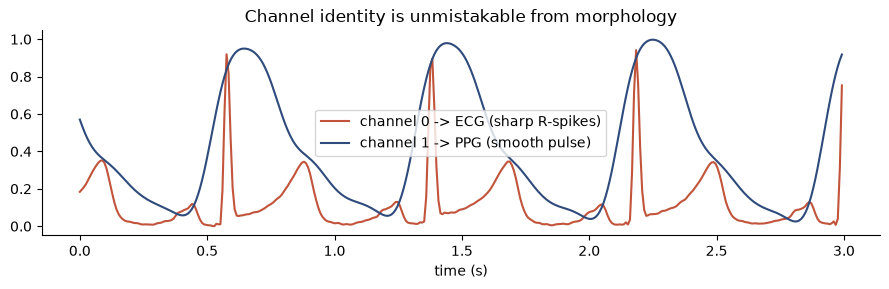

In [5]:
n = int(3 * fs)
fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(t[:n], Xtr[0, :n, 0], color=RED,  label="channel 0 -> ECG (sharp R-spikes)")
ax.plot(t[:n], Xtr[0, :n, 1], color=NAVY, label="channel 1 -> PPG (smooth pulse)")
ax.set_xlabel("time (s)"); ax.set_title("Channel identity is unmistakable from morphology")
ax.legend(); fig.tight_layout(); plt.show()

## A fast baseline, and the causal PTT audit

Because ECG/PPG are amplitude-normalized and this subset has no per-subject calibration
anchor, a single window cannot fix a subject's absolute BP -- so a small model sits near
the predict-the-mean baseline. What matters for *faithfulness* is the causal audit: shift
the PPG in time to change transit time (PTT) and see whether predicted BP responds in the


In [6]:
import torch, torch.nn as nn
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
Xte, yte = d["Xte"], d["yte"]
Xtr2 = mechlib.normalize(Xtr[:, :, [mechlib.ECG, mechlib.PPG]])
Xte2 = mechlib.normalize(Xte[:, :, [mechlib.ECG, mechlib.PPG]])

class SmallCNN(nn.Module):
    def __init__(self, w=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(2, w, 7, 2, 3), nn.ReLU(), nn.Conv1d(w, w*2, 7, 2, 3), nn.ReLU(),
            nn.Conv1d(w*2, w*2, 7, 2, 3), nn.ReLU(), nn.AdaptiveAvgPool1d(1), nn.Flatten(), nn.Linear(w*2, 2))
    def forward(self, x): return self.net(x.transpose(1, 2))

torch.manual_seed(0); net = SmallCNN().to(device); opt = torch.optim.Adam(net.parameters(), 2e-3)
Xt = torch.tensor(Xtr2, device=device); yt = torch.tensor(ytr, device=device)
for ep in range(40):
    net.train(); perm = torch.randperm(len(Xt))
    for s in range(0, len(Xt), 128):
        b = perm[s:s+128]; loss = ((net(Xt[b]) - yt[b])**2).mean()
        opt.zero_grad(); loss.backward(); opt.step()
pred = mechlib.predict(net, Xte2, device)
base = np.abs(yte - ytr.mean(0)).mean(0)
print(f"test MAE  SBP {np.abs(pred-yte)[:,0].mean():.1f}  DBP {np.abs(pred-yte)[:,1].mean():.1f} mmHg"
      f"   (predict-mean baseline SBP {base[0]:.1f})")

test MAE  SBP 14.3  DBP 9.3 mmHg   (predict-mean baseline SBP 14.8)


PTT median 380 ms
dBP/dPTT +5.37 mmHg/s   frac correct sign 0.38  (physiological = negative)


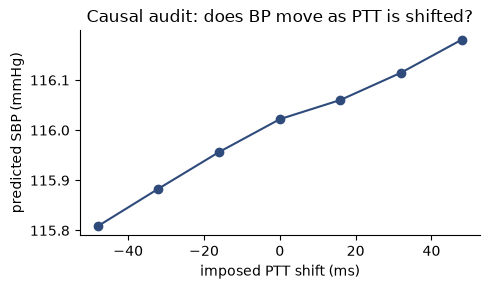

In [7]:
ptt = mechlib.compute_ptt(Xte2, fs, ecg_pos=0, ppg_pos=1)
au = mechlib.causal_ptt_audit(net, Xte2, fs, device, ppg_pos=1)
print(f"PTT median {np.nanmedian(ptt)*1000:.0f} ms")
print(f"dBP/dPTT {au['dBP_dPTT']:+.2f} mmHg/s   frac correct sign {au['frac_correct_sign']:.2f}  (physiological = negative)")
plt.figure(figsize=(5,3))
plt.plot(au["shift_ms"], au["curve_sbp"], "-o", color=NAVY)
plt.xlabel("imposed PTT shift (ms)"); plt.ylabel("predicted SBP (mmHg)")
plt.title("Causal audit: does BP move as PTT is shifted?"); plt.tight_layout(); plt.show()

A near-baseline model that also fails the causal audit is the honest starting point.
The **models** notebook makes the model genuinely accurate with calibration and shows the
